In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

print("OK")

OK


In [6]:
data = pd.read_csv("data/Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
# Display general information about dataset (data types, missing values)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [9]:
# Display statistical summary of numerical columns
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
# Remove irrelevant columns that do not contribute to prediction
# These columns are identifiers and have no predictive value
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [11]:
# Convert categorical variables (text) into numerical values
from sklearn.preprocessing import LabelEncoder

le_geo = LabelEncoder()
le_gender = LabelEncoder()

data['Geography'] = le_geo.fit_transform(data['Geography'])
data['Gender'] = le_gender.fit_transform(data['Gender'])

In [12]:
# Separate input features (X) and target variable (y)
# 'Exited' is the target (0 = stayed, 1 = left)
X = data.drop('Exited', axis=1)
y = data['Exited']

In [13]:
#Split data into train/test sets
from sklearn.model_selection import train_test_split

# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=101
)

In [14]:
#Scaling

from sklearn.preprocessing import StandardScaler

# Normalize feature values to improve neural network performance
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
#Create model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Create a sequential neural network model
model = Sequential()

# Define input layer
model.add(Input(shape=(X_train.shape[1],)))

# Add hidden layers with ReLU activation
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))

# Output layer with sigmoid activation for binary classification
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model with optimizer, loss function and evaluation metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train the neural network on training data
# Validate the model on test data during training
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7641 - loss: 0.5468 - val_accuracy: 0.7927 - val_loss: 0.4722
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7984 - loss: 0.4517 - val_accuracy: 0.7943 - val_loss: 0.4318
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8124 - loss: 0.4206 - val_accuracy: 0.8230 - val_loss: 0.4004
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8376 - loss: 0.3965 - val_accuracy: 0.8427 - val_loss: 0.3777
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8434 - loss: 0.3795 - val_accuracy: 0.8473 - val_loss: 0.3653
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.3700 - val_accuracy: 0.8510 - val_loss: 0.3591
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8491 - loss: 0.3639 - val_accuracy: 0.8510 - val_loss: 0.3540
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8534 - loss: 0.3590 - val_accuracy: 0.

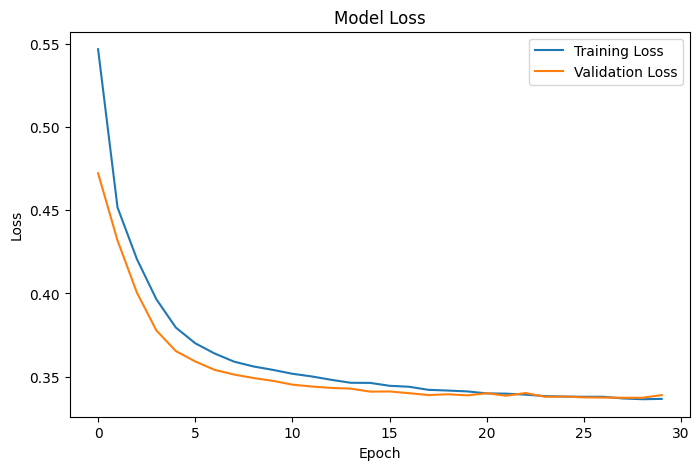

In [20]:
import matplotlib.pyplot as plt

# Plot training and validation loss to monitor learning process
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

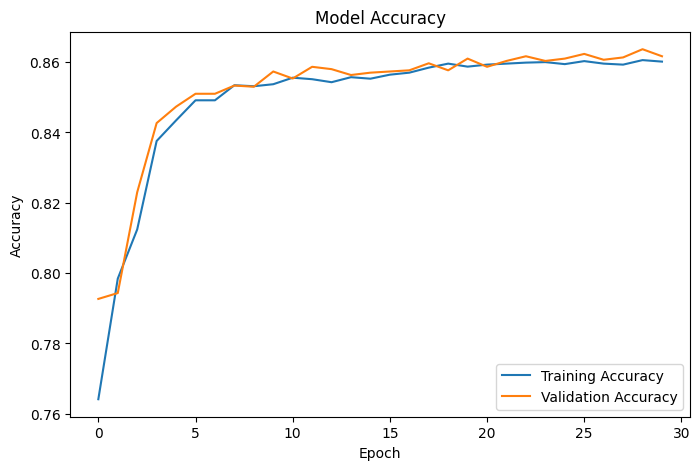

In [23]:
# Plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

In [21]:
# Predict probabilities for test data
y_pred_prob = model.predict(X_test)

# Convert probabilities into binary predictions (threshold = 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [22]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8616666666666667

Confusion Matrix:
[[2273  105]
 [ 310  312]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      2378
           1       0.75      0.50      0.60       622

    accuracy                           0.86      3000
   macro avg       0.81      0.73      0.76      3000
weighted avg       0.85      0.86      0.85      3000



In [ ]:
# Conclusion:
# In this lab was built an Artificial Neural Network (ANN) for binary classification.
# The dataset was preprocessed by removing irrelevant columns and encoding categorical variables.
# The data was split into training and testing sets and scaled for better performance.
# A neural network model with Dense layers was created and trained using the Adam optimizer.
# The model was evaluated using accuracy, confusion matrix, and classification report.
# The results demonstrate that the neural network can effectively predict customer churn.